# Analisis Eksplorasi (EDA) Faktor Pendorong Happiness Score

**Tujuan:** Mengeksplorasi pola, distribusi, dan hubungan antara Happiness Score ($y$) dengan variabel penjelasnya, menggunakan data gabungan World Happiness Report (2025) dan data populasi/geografi negara.

**Alur analisis:**
1. Load & pahami struktur dataset
2. Cleaning & penanganan missing values
3. EDA univariat — distribusi Happiness Score & driver-nya
4. EDA bivariat — korelasi & hubungan terhadap $y$
5. EDA per waktu & per benua
6. Cek multikolinearitas (VIF) & regresi OLS sebagai *alat bantu* EDA (bukan model final)
7. Ringkasan temuan

> Catatan: Notebook ini fokus pada eksplorasi data (EDA). Model regresi di bagian akhir dipakai sebagai alat bantu untuk mengukur kekuatan hubungan antar variabel, bukan sebagai model prediktif final.

## 1. Persiapan Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 2. Load Dataset

Dataset merupakan hasil scraping & merge dari:
- **Worldometers** (daftar negara, luas wilayah, benua)
- **Our World in Data** (populasi historis + proyeksi UN)
- **World Happiness Report 2025** (Figure 2.1 — Happiness Score & 6 variabel penjelas)

In [2]:
dataset = pd.read_csv('dataset_country_population_happiness.csv')
print('Shape awal:', dataset.shape)
dataset.head()


Shape awal: (17550, 17)


,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²),Happiness Rank,Happiness Score,Lower whisker,Upper whisker,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption,Dystopia_Residual
0,Afghanistan,Asia,2011,29347708.0,652860,44.95,131.0,4.258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Asia,2012,30560036.0,652860,46.81,143.0,4.040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,Asia,2013,31622709.0,652860,48.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Asia,2014,32792528.0,652860,50.23,153.0,3.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Asia,2015,33831767.0,652860,51.82,154.0,3.360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 17550 entries, 0 to 17549
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    17550 non-null  str    
 1   Continent                  17550 non-null  str    
 2   Year                       17550 non-null  int64  
 3   Population                 17550 non-null  float64
 4   Land Area (Km²)            17550 non-null  int64  
 5   Density (P/Km²)            17550 non-null  float64
 6   Happiness Rank             1915 non-null   float64
 7   Happiness Score            1915 non-null   float64
 8   Lower whisker              854 non-null    float64
 9   Upper whisker              854 non-null    float64
 10  GDP_per_Capita             851 non-null    float64
 11  Social_Support             851 non-null    float64
 12  Healthy_Life_Expectancy    849 non-null    float64
 13  Freedom                    850 non-null    float64
 14  G

### Ringkasan missing values per kolom

Sebelum membersihkan data, cek dulu pola *missingness*-nya — ini penting karena `Happiness Score` dan driver-nya ternyata tidak tersedia untuk seluruh baris (dataset mencakup proyeksi populasi hingga 2100, jauh melebihi cakupan WHR).

In [4]:
missing_summary = pd.DataFrame({
    'Non-Null': dataset.notna().sum(),
    'Missing': dataset.isna().sum(),
    'Missing (%)': (dataset.isna().mean() * 100).round(1)
}).sort_values('Missing (%)', ascending=False)

missing_summary


,Non-Null,Missing,Missing (%)
Freedom,850,16700,95.2
Social_Support,851,16699,95.2
Dystopia_Residual,847,16703,95.2
Generosity,851,16699,95.2
Perceptions_of_Corruption,850,16700,95.2
GDP_per_Capita,851,16699,95.2
Healthy_Life_Expectancy,849,16701,95.2
Upper whisker,854,16696,95.1
Lower whisker,854,16696,95.1
Happiness Score,1915,15635,89.1


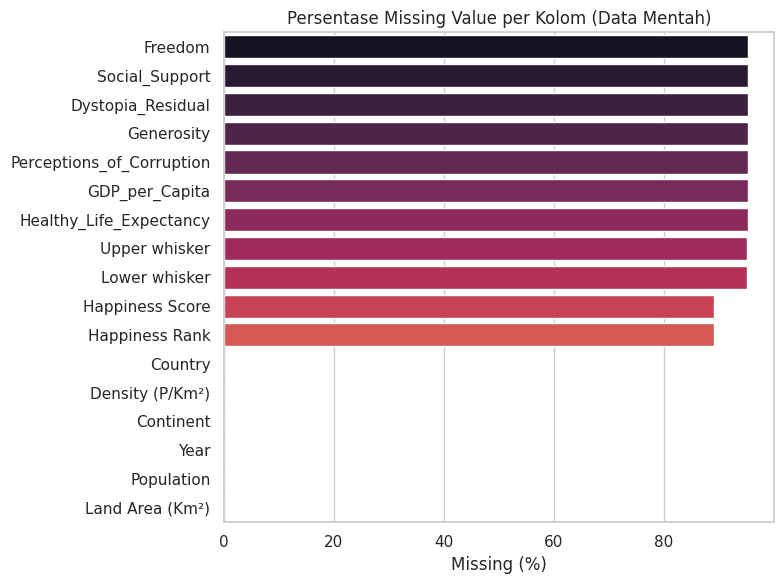

In [5]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=missing_summary['Missing (%)'],
    y=missing_summary.index,
    hue=missing_summary.index,
    palette='rocket',
    legend=False
)
plt.title('Persentase Missing Value per Kolom (Data Mentah)')
plt.xlabel('Missing (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 3. Cleaning Data

- Filter hanya baris dengan `Happiness Score` terisi (data proyeksi populasi 2025–2100 tidak relevan untuk analisis kebahagiaan)
- Batasi ke tahun 2011–2024 (rentang data aktual WHR, bukan proyeksi populasi)
- Tangani potensi nilai `inf` pada Density akibat pembagian oleh Land Area
- Cek duplikat baris (Country, Year)

In [6]:
data = dataset[
    (dataset['Year'].between(2011, 2024)) &
    (dataset['Happiness Score'].notna())
].copy()

data['Density (P/Km²)'] = data['Density (P/Km²)'].replace([np.inf, -np.inf], np.nan)

n_dupes = data.duplicated(subset=['Country', 'Year']).sum()

print('Shape setelah filter:', data.shape)
print('Tahun:', sorted(data['Year'].unique()))
print('Jumlah negara:', data['Country'].nunique())
print('Baris duplikat (Country, Year):', n_dupes)


Shape setelah filter: (1915, 17)
Tahun: [np.int64(2011), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Jumlah negara: 161
Baris duplikat (Country, Year): 0


### Cek ketersediaan variabel driver per tahun

Variabel `GDP_per_Capita`, `Social_Support`, dll. ('Explained by...' pada WHR) ternyata **hanya tersedia untuk tahun 2019–2024** pada file Figure 2.1 WHR25. Tahun 2011–2018 hanya memiliki `Happiness Score` tanpa breakdown driver — ini kita pertahankan untuk eksplorasi tren Happiness Score jangka panjang, dan baru dipersempit ke 2019–2024 saat mengeksplorasi hubungan dengan driver.

In [7]:
drivers = [
    'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy',
    'Freedom', 'Generosity', 'Perceptions_of_Corruption'
]

availability = data.groupby('Year')['GDP_per_Capita'].apply(lambda x: x.notna().sum())
total_rows = data.groupby('Year').size()

pd.DataFrame({'Total Baris': total_rows, 'Baris dengan Driver Terisi': availability})


,Total Baris,Baris dengan Driver Terisi
Year,,
2011,151,0
2012,151,0
2014,153,0
2015,151,0
2016,151,0
2017,152,0
2018,152,0
2019,149,149
2020,145,145


In [8]:
# Data lengkap tahun 2011-2024, khusus Happiness Score (untuk EDA tren jangka panjang)
long_data = data.copy()

# Batasi ke tahun dengan data driver lengkap (untuk EDA hubungan antar-variabel)
eda_data = data[data['Year'] >= 2019].copy()
eda_data = eda_data.dropna(subset=drivers + ['Happiness Score'])

print('Shape data driver lengkap (2019-2024):', eda_data.shape)
print('Tahun:', sorted(eda_data['Year'].unique()))
print('Jumlah negara:', eda_data['Country'].nunique())

panel_counts = eda_data.groupby('Country')['Year'].nunique()
print('\nDistribusi jumlah tahun per negara:')
print(panel_counts.value_counts().sort_index())


Shape data driver lengkap (2019-2024): (847, 17)
Tahun: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Jumlah negara: 151

Distribusi jumlah tahun per negara:
Year
1      4
2      4
3      4
4      2
5      7
6    130
Name: count, dtype: int64


## 4. EDA Univariat — Distribusi Happiness Score & Driver

Sebelum melihat hubungan antar variabel, kita lihat dulu bentuk distribusi masing-masing variabel: apakah normal, skewed, atau ada outlier yang mencolok.

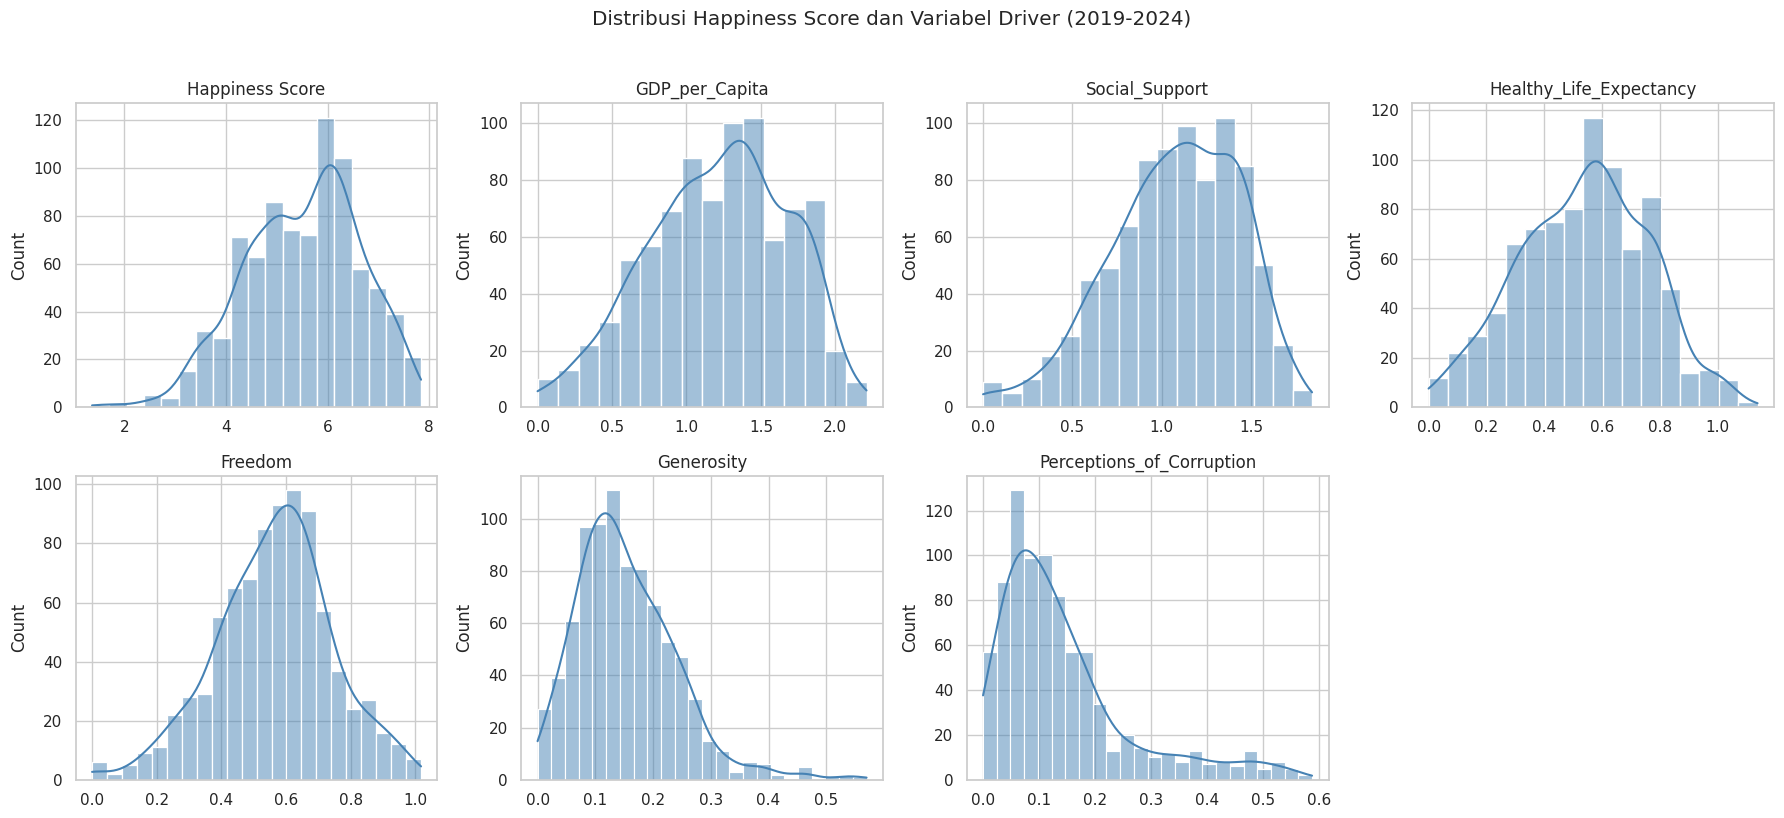

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cols_to_plot = ['Happiness Score'] + drivers
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(eda_data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# sembunyikan subplot kosong
for j in range(len(cols_to_plot), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Happiness Score dan Variabel Driver (2019-2024)', y=1.02)
plt.tight_layout()
plt.show()


In [10]:
eda_data[['Happiness Score'] + drivers].describe().T


,count,mean,std,min,25%,50%,75%,max
Happiness Score,847.0,5.522465,1.132217,1.364,4.723500,5.6741,6.337500,7.842000
GDP_per_Capita,847.0,1.212676,0.464402,0.000,0.894000,1.2560,1.558000,2.209000
Social_Support,847.0,1.074813,0.357433,0.000,0.843500,1.1020,1.361000,1.840000
Healthy_Life_Expectancy,847.0,0.537457,0.221276,0.000,0.379156,0.5490,0.701500,1.137814
Freedom,847.0,0.563442,0.181156,0.000,0.450027,0.5730,0.677000,1.018000
Generosity,847.0,0.153849,0.086613,0.000,0.092000,0.1400,0.205000,0.569814
Perceptions_of_Corruption,847.0,0.143008,0.119781,0.000,0.061000,0.1120,0.178932,0.587000


### Deteksi outlier dengan boxplot

Boxplot membantu melihat sebaran dan potensi outlier tiap variabel driver secara sekaligus (semua sudah dalam skala 0-Score WHR sehingga cukup sebanding).

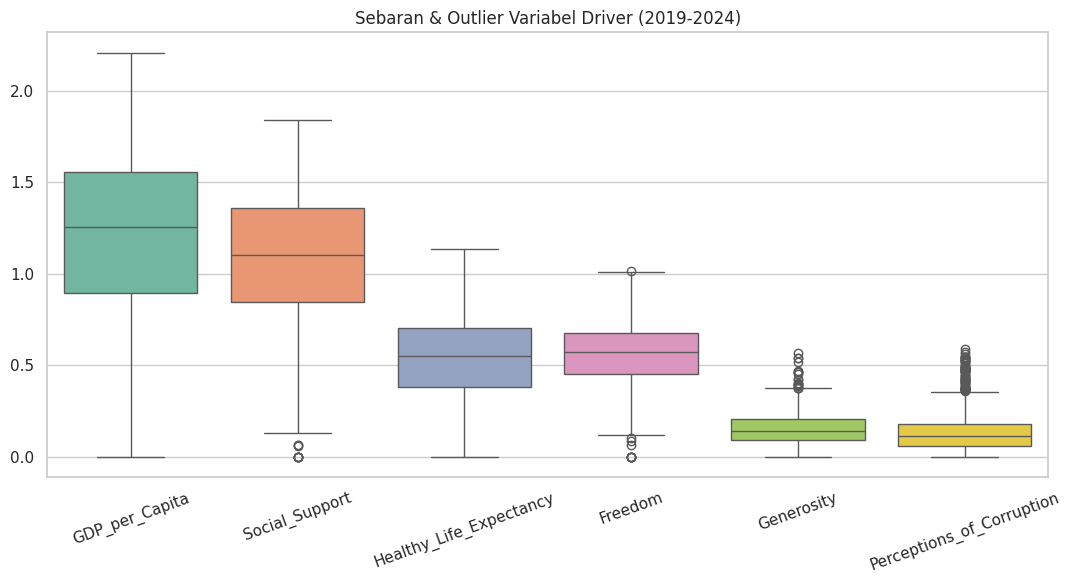

In [11]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=eda_data[drivers], palette='Set2')
plt.title('Sebaran & Outlier Variabel Driver (2019-2024)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Negara dengan Happiness Score tertinggi & terendah

Melihat langsung negara mana yang berada di dua ujung distribusi memberi konteks kualitatif sebelum masuk ke analisis kuantitatif.

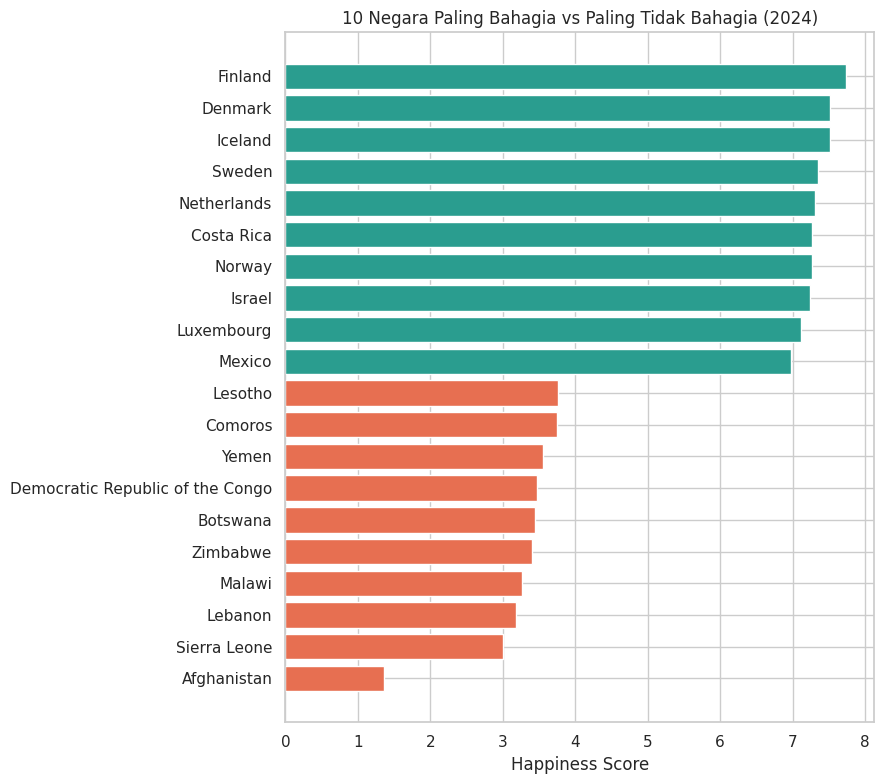

In [12]:
latest_year = eda_data['Year'].max()
latest = eda_data[eda_data['Year'] == latest_year].sort_values('Happiness Score', ascending=False)

top_bottom = pd.concat([
    latest[['Country', 'Continent', 'Happiness Score']].head(10).assign(Kelompok='Top 10'),
    latest[['Country', 'Continent', 'Happiness Score']].tail(10).assign(Kelompok='Bottom 10')
])

fig, ax = plt.subplots(figsize=(9, 8))
colors = top_bottom['Kelompok'].map({'Top 10': '#2a9d8f', 'Bottom 10': '#e76f51'})
ax.barh(top_bottom['Country'], top_bottom['Happiness Score'], color=colors)
ax.invert_yaxis()
ax.set_title(f'10 Negara Paling Bahagia vs Paling Tidak Bahagia ({int(latest_year)})')
ax.set_xlabel('Happiness Score')
plt.tight_layout()
plt.show()


## 5. EDA Bivariat — Hubungan terhadap $y$ (Happiness Score)

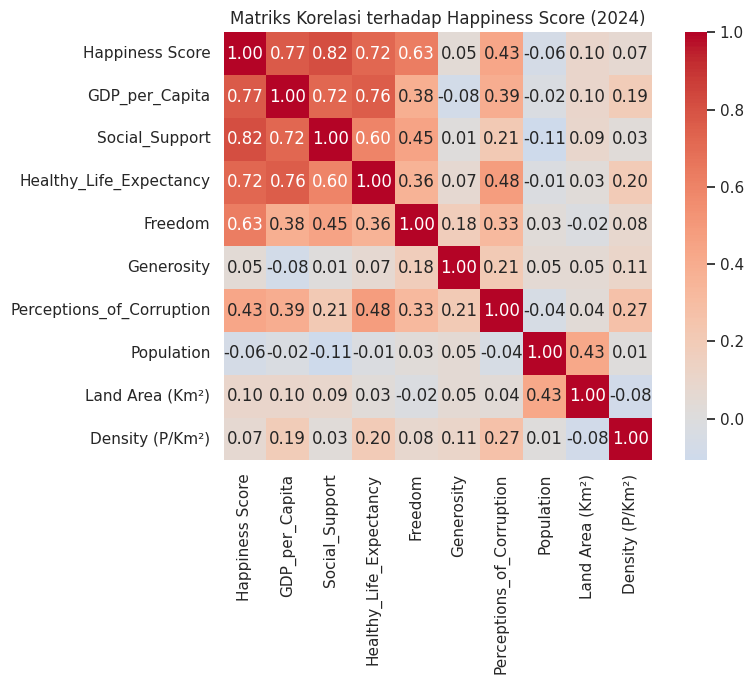

In [13]:
corr_cols = ['Happiness Score'] + drivers + ['Population', 'Land Area (Km²)', 'Density (P/Km²)']

corr_latest = eda_data[eda_data['Year'] == latest_year]
correlation = corr_latest[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title(f'Matriks Korelasi terhadap Happiness Score ({int(latest_year)})')
plt.tight_layout()
plt.show()


In [14]:
print('=== Korelasi terhadap Happiness Score (diurutkan) ===')
print(correlation['Happiness Score'].drop('Happiness Score').sort_values(ascending=False))


=== Korelasi terhadap Happiness Score (diurutkan) ===
Social_Support               0.817513
GDP_per_Capita               0.769640
Healthy_Life_Expectancy      0.720208
Freedom                      0.632090
Perceptions_of_Corruption    0.428857
Land Area (Km²)              0.098527
Density (P/Km²)              0.066712
Generosity                   0.045389
Population                  -0.061502
Name: Happiness Score, dtype: float64


### Scatter plot — driver dengan korelasi terkuat

Korelasi tertinggi ada pada `Social_Support`, `GDP_per_Capita`, dan `Healthy_Life_Expectancy`. Scatter plot dengan garis regresi membantu melihat apakah hubungannya memang linear, atau ada pola melengkung/outlier yang tidak tertangkap angka korelasi saja.

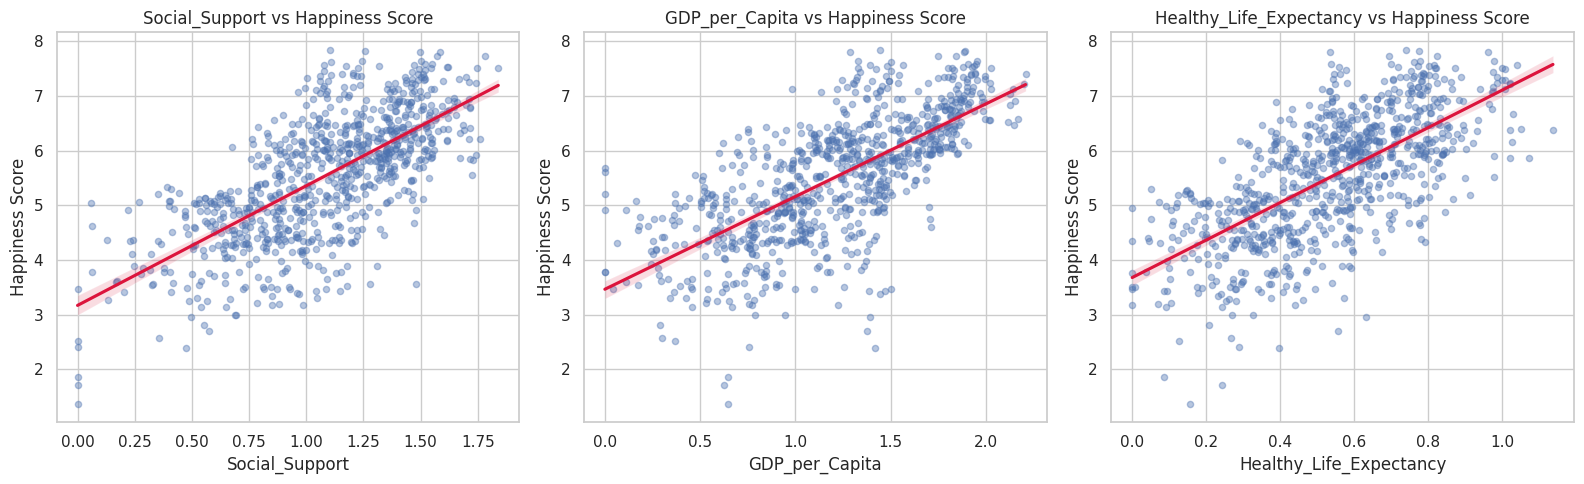

In [15]:
top3_drivers = correlation['Happiness Score'].drop('Happiness Score').sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, top3_drivers):
    sns.regplot(data=eda_data, x=col, y='Happiness Score', ax=ax,
                scatter_kws={'alpha': 0.4, 's': 20}, line_kws={'color': 'crimson'})
    ax.set_title(f'{col} vs Happiness Score')

plt.tight_layout()
plt.show()


### Pairplot — hubungan antar seluruh driver sekaligus

Pairplot memberi gambaran cepat semua hubungan pasangan variabel sekaligus, termasuk mengecek apakah ada driver yang terlalu mirip satu sama lain (indikasi awal multikolinearitas sebelum VIF).

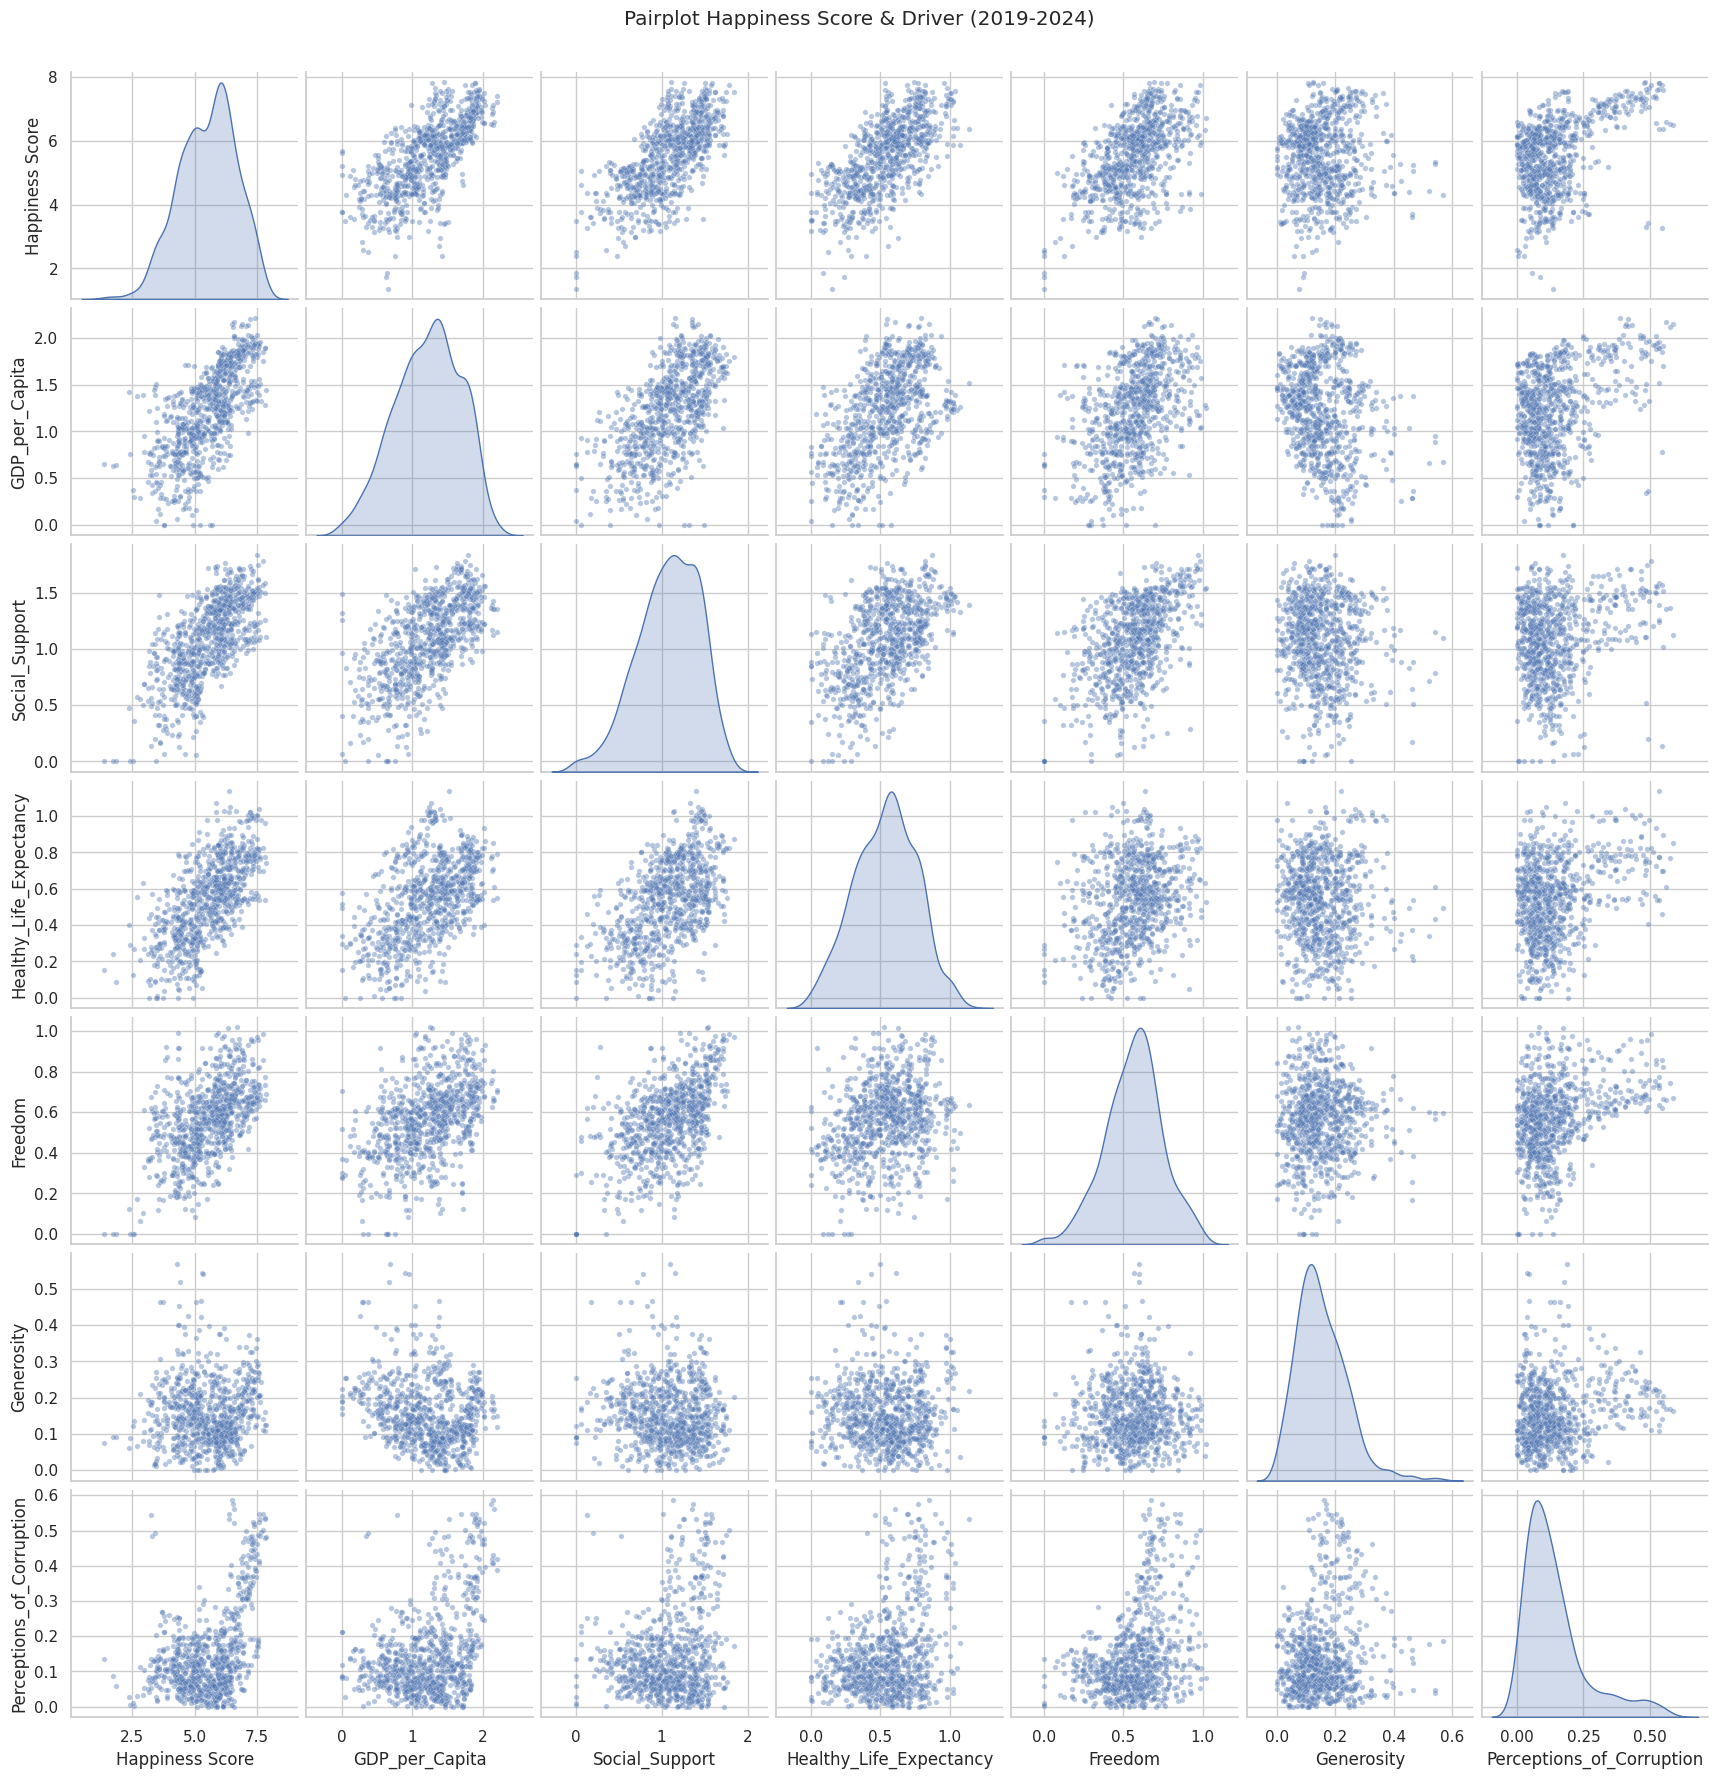

In [16]:
sns.pairplot(
    eda_data[['Happiness Score'] + drivers],
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15}
)
plt.suptitle('Pairplot Happiness Score & Driver (2019-2024)', y=1.02)
plt.show()


## 6. EDA per Waktu & per Benua

### Tren rata-rata Happiness Score dunia dari waktu ke waktu

Menggunakan `long_data` (2011-2024) karena Happiness Score sendiri tersedia sejak 2011, meski breakdown driver baru ada dari 2019.

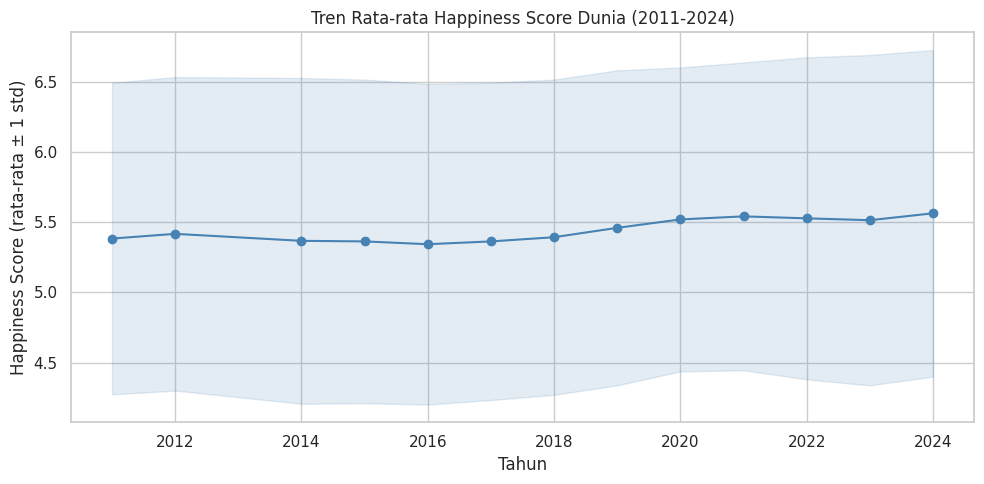

In [17]:
yearly_trend = long_data.groupby('Year')['Happiness Score'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_trend['Year'], yearly_trend['mean'], marker='o', color='steelblue')
plt.fill_between(
    yearly_trend['Year'],
    yearly_trend['mean'] - yearly_trend['std'],
    yearly_trend['mean'] + yearly_trend['std'],
    alpha=0.15, color='steelblue'
)
plt.title('Tren Rata-rata Happiness Score Dunia (2011-2024)')
plt.xlabel('Tahun')
plt.ylabel('Happiness Score (rata-rata ± 1 std)')
plt.tight_layout()
plt.show()


### Rata-rata Happiness Score per benua

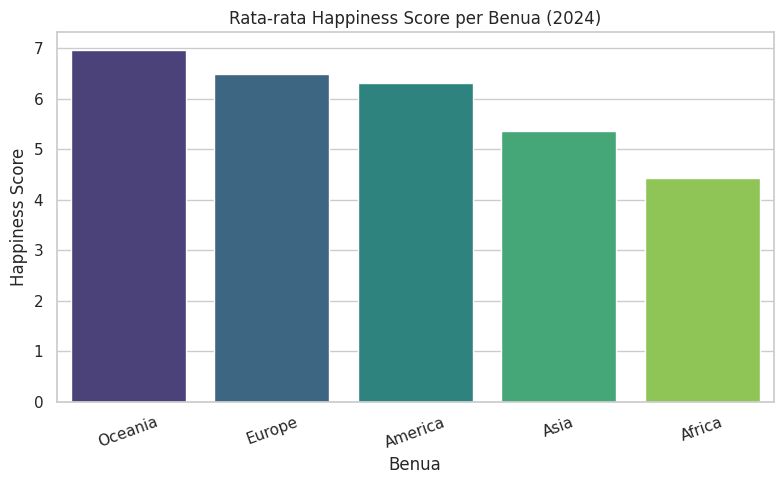

In [18]:
continent_happiness = (
    eda_data[eda_data['Year'] == latest_year]
    .groupby('Continent')['Happiness Score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=continent_happiness.index, y=continent_happiness.values,
            hue=continent_happiness.index, palette='viridis', legend=False)
plt.title(f'Rata-rata Happiness Score per Benua ({int(latest_year)})')
plt.ylabel('Happiness Score')
plt.xlabel('Benua')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Sebaran Happiness Score per benua (boxplot)

Rata-rata saja bisa menyembunyikan variasi dalam satu benua — boxplot menunjukkan seberapa besar kesenjangan happiness *di dalam* tiap benua.

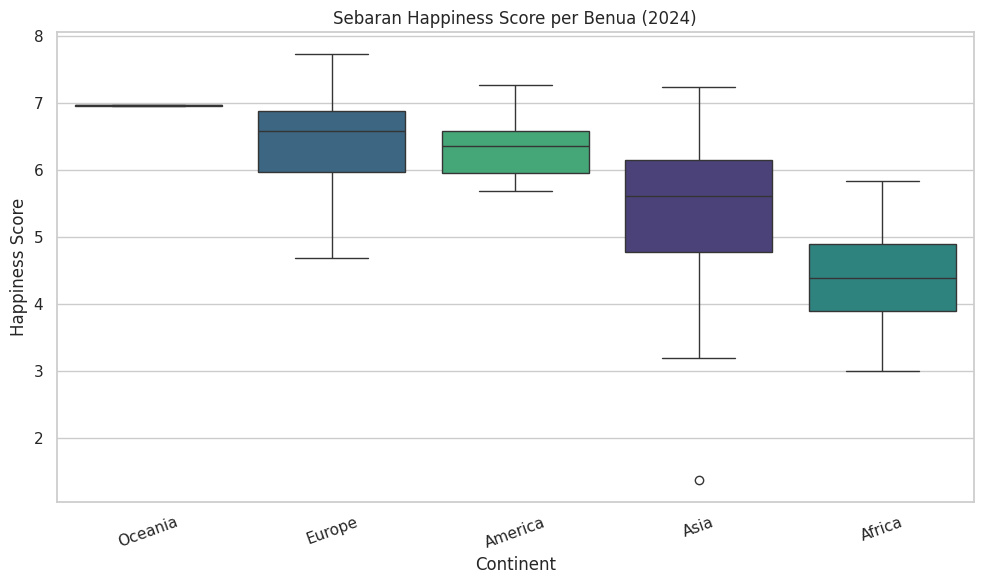

In [19]:
plt.figure(figsize=(10, 6))
order = eda_data[eda_data['Year'] == latest_year].groupby('Continent')['Happiness Score'].median().sort_values(ascending=False).index
sns.boxplot(data=eda_data[eda_data['Year'] == latest_year], x='Continent', y='Happiness Score',
            order=order, hue='Continent', palette='viridis', legend=False)
plt.title(f'Sebaran Happiness Score per Benua ({int(latest_year)})')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7. Kekuatan Hubungan Gabungan — VIF & OLS sebagai Alat Bantu EDA

Korelasi & scatter plot di atas melihat tiap variabel **satu per satu**. Untuk melengkapi eksplorasi, kita pakai regresi OLS sederhana sebagai *alat bantu* untuk melihat kekuatan hubungan tiap driver **ketika variabel lain dikontrol** — bukan sebagai model prediktif final, jadi tidak ada proses train/test split, tuning, maupun validasi performa.

Sebelum itu, cek dulu multikolinearitas antar driver (VIF > 5-10 mengindikasikan masalah — bila tinggi, korelasi individual antar driver bisa saling tumpang tindih dan koefisien regresi jadi kurang bisa diandalkan).

In [20]:
X_vif = sm.add_constant(eda_data[drivers])

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data


,Variable,VIF
0,const,1.000000
1,GDP_per_Capita,2.131575
2,Social_Support,2.147661
3,Healthy_Life_Expectancy,1.583041
4,Freedom,1.567678
5,Generosity,1.145877
6,Perceptions_of_Corruption,1.362815


**Interpretasi:** Seluruh VIF di bawah ambang batas 5, jadi tidak ada masalah multikolinearitas serius — aman melanjutkan ke regresi OLS sebagai alat bantu eksplorasi.

In [21]:
X = sm.add_constant(eda_data[drivers])
y = eda_data['Happiness Score']

ols_model = sm.OLS(y, X).fit(cov_type='HC3')  # robust standard errors
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:        Happiness Score   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     337.4
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          8.04e-220
Time:                        09:28:43   Log-Likelihood:                -764.61
No. Observations:                 847   AIC:                             1543.
Df Residuals:                     840   BIC:                             1576.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

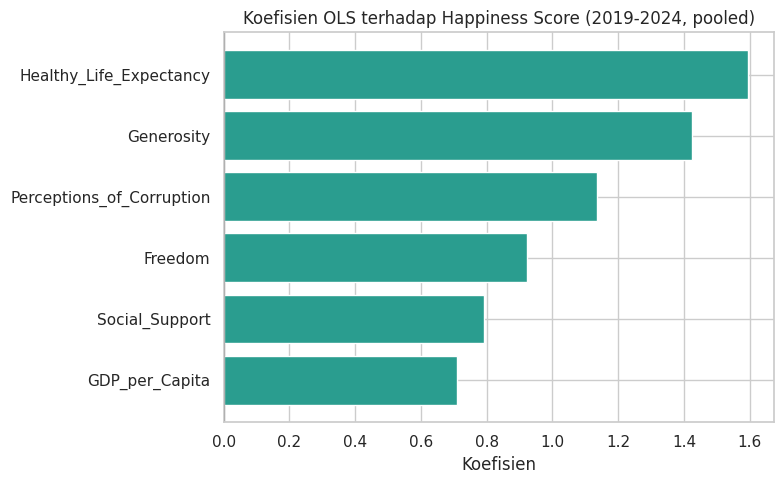

In [22]:
ols_coefs = ols_model.params.drop('const').sort_values()

plt.figure(figsize=(8, 5))
colors = ['#e76f51' if v < 0 else '#2a9d8f' for v in ols_coefs.values]
plt.barh(ols_coefs.index, ols_coefs.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Koefisien OLS terhadap Happiness Score (2019-2024, pooled)')
plt.xlabel('Koefisien')
plt.tight_layout()
plt.show()


## 8. Ringkasan Temuan EDA

### Kualitas & Cakupan Data
- Dataset mentah berisi 17.550 baris (termasuk proyeksi populasi hingga 2100); setelah difilter ke baris dengan Happiness Score terisi (2011-2024), tersisa 1.915 baris dari 161 negara.
- Breakdown driver (`GDP_per_Capita`, `Social_Support`, dll.) hanya tersedia untuk 2019-2024 — analisis hubungan antar-variabel difokuskan ke rentang ini (847 baris, 151 negara).
- Tidak ditemukan baris duplikat (Country, Year), dan tidak ada nilai `inf` tersisa pada Density setelah pembersihan.

### Pola Distribusi
- Happiness Score relatif mendekati distribusi normal dengan sedikit variasi ekor di kedua sisi; driver seperti `Generosity` dan `Perceptions_of_Corruption` cenderung *right-skewed* (banyak negara dengan nilai rendah, sedikit dengan nilai tinggi).
- Kesenjangan Happiness Score antara 10 negara teratas dan 10 negara terbawah sangat besar, mengonfirmasi variasi kebahagiaan antarnegara sangat lebar.

### Hubungan terhadap Happiness Score
- **Social_Support**, **GDP_per_Capita**, dan **Healthy_Life_Expectancy** memiliki korelasi terkuat terhadap Happiness Score (masing-masing di atas 0.7), dan scatter plot menunjukkan hubungan yang cukup linear.
- **Freedom** berkorelasi sedang-kuat; **Perceptions_of_Corruption** berkorelasi sedang; **Generosity**, populasi, luas wilayah, dan kepadatan penduduk hampir tidak berkorelasi dengan kebahagiaan.
- VIF seluruh driver berada jauh di bawah ambang batas 5, sehingga tidak ada masalah multikolinearitas yang mendistorsi interpretasi hubungan individual.
- Regresi OLS (sebagai alat bantu EDA, bukan model prediktif) mengonfirmasi arah dan kekuatan hubungan yang konsisten dengan korelasi: `Healthy_Life_Expectancy`, `GDP_per_Capita`, dan `Social_Support` memiliki koefisien positif terbesar.

### Pola per Waktu & Wilayah
- Rata-rata Happiness Score dunia relatif stabil dari 2011-2024, dengan sedikit fluktuasi antar tahun.
- Terdapat perbedaan rata-rata Happiness Score yang cukup jelas antar benua, dengan variasi *dalam* benua yang juga cukup besar (terlihat dari boxplot per benua) — artinya benua bukan penentu tunggal, karena tetap ada negara-negara dengan skor jauh dari rata-rata benuanya.

### Catatan Lanjutan
- Analisis ini murni eksploratif; untuk klaim sebab-akibat atau efek kebijakan (mis. panel fixed-effects, causal inference) diperlukan tahap pemodelan terpisah di luar cakupan notebook ini.
- Karena Happiness Score dalam sumber WHR merupakan rata-rata bergulir 3 tahun, variasi tahun-ke-tahun dalam satu negara cenderung halus — perlu diperhitungkan bila melakukan analisis time-series lanjutan.